# Functions

## Graphing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    "font.size": 14,          # base font size
    "axes.titlesize": 16,     # title
    "axes.labelsize": 14,     # x/y labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# T1 graph
def inversion_recovery(tau, V, lbl):
    """
    Fit inversion-recovery data to the absolute-value model

        S(tau) = A * |1 - 2 exp(-tau / T1)| + C

    Parameters
    ----------
    tau : array-like
        Delay times.
    V : array-like
        Measured voltages.

    Returns
    -------
    popt : ndarray
        Best-fit parameters [A, T1, C]
    pcov : ndarray
        Covariance matrix from curve_fit
    """
    tau = np.asarray(tau, dtype=float)
    V = np.asarray(V, dtype=float)

    if tau.shape != V.shape:
        raise ValueError("tau and V must have the same shape")
    if tau.ndim != 1:
        raise ValueError("tau and V must be 1D arrays")
    if np.any(tau <= 0):
        raise ValueError("All tau values must be positive")

    # Sort by tau in case input is unordered
    order = np.argsort(tau)
    tau = tau[order]
    V = V[order]

    def model(t, A, T1, C):
        return A * np.abs(1 - 2 * np.exp(-t / T1)) + C

    # Rough initial guesses
    C0 = np.min(V)
    A0 = np.max(V) - C0

    # Estimate cusp location from minimum
    tau0_guess = tau[np.argmin(V)]
    T10 = tau0_guess / np.log(2) if tau0_guess > 0 else np.median(tau)

    # Keep T1 positive
    p0 = [A0, T10, C0]
    bounds = ([0, 0, -np.inf], [np.inf, np.inf, np.inf])

    popt, pcov = curve_fit(model, tau, V, p0=p0, bounds=bounds, maxfev=10000)

    A_fit, T1_fit, C_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # Smooth curve for plotting
    tau_fit = np.linspace(np.min(tau), np.max(tau), 1000)
    V_fit = model(tau_fit, *popt)

    # Estimated cusp / zero-crossing location
    tau0_fit = T1_fit * np.log(2)

    plt.figure(figsize=(8, 5))
    plt.scatter(tau, V, label=f'{lbl} data', color='k', marker='x')
    plt.plot(tau_fit, V_fit, label=f"Fit: {A_fit:.2f}|1 - 2e^(-{1/T1_fit:.2f}τ)| + {C_fit:.2f}", color='r')
    plt.axvline(tau0_fit, linestyle="--", label=fr"$\tau_0 = T_1 \ln 2 = {tau0_fit:.4g}$")
    plt.xlabel(r"$\tau$ (s)")
    plt.ylabel("Pulse B max FID amplitude (V)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"A  = {A_fit:.6g} ± {perr[0]:.6g}")
    print(f"T1 = {T1_fit:.6g} ± {perr[1]:.6g}")
    print(f"C  = {C_fit:.6g} ± {perr[2]:.6g}")

    return popt, pcov

# T2 graph
def spin_echo(tau, A_echo, plot=True, lbl=None):
    """
    Fit spin-echo amplitudes:

        A_echo(tau) = A0 exp(-2 tau / T2) + C

    Returns
    -------
    result : dict
        Contains fit parameters, covariance, sorted data, and smooth fit curve.
    """
    tau = np.asarray(tau, dtype=float)
    A_echo = np.asarray(A_echo, dtype=float)

    if tau.shape != A_echo.shape:
        raise ValueError("tau and A_echo must have the same shape.")
    if tau.ndim != 1:
        raise ValueError("tau and A_echo must be 1D arrays.")
    if len(tau) < 3:
        raise ValueError("Need at least 3 data points.")
    if np.any(tau < 0):
        raise ValueError("tau values must be nonnegative.")

    order = np.argsort(tau)
    tau = tau[order]
    A_echo = A_echo[order]

    def model(t, A0, T2, C):
        return A0 * np.exp(-2 * t / T2) + C

    C0 = np.min(A_echo)
    A0_guess = np.max(A_echo) - C0
    target = C0 + A0_guess / np.e
    idx = np.argmin(np.abs(A_echo - target))
    T2_guess = 2 * tau[idx] if tau[idx] > 0 else max(np.median(tau), 1e-3)

    popt, pcov = curve_fit(
        model,
        tau,
        A_echo,
        p0=[A0_guess, T2_guess, C0],
        bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
        maxfev=10000,
    )
    perr = np.sqrt(np.diag(pcov))

    tau_fit = np.linspace(np.min(tau), np.max(tau), 1000)
    A_fit = model(tau_fit, *popt)

    result = {
        "popt": popt,
        "pcov": pcov,
        "A0": popt[0],
        "T2": popt[1],
        "C": popt[2],
        "tau_data": tau,
        "A_data": A_echo,
        "tau_fit": tau_fit,
        "A_fit": A_fit,
        "model": model,
    }

    if plot:
        plt.figure(figsize=(8, 5))
        plt.scatter(tau, A_echo, color="black", marker="x", label=f"{lbl} data")
        plt.plot(
            tau_fit,
            A_fit,
            color="red",
            label=fr"Fit: ${popt[0]:.3g}\exp\!\left(-\frac{{2\tau}}{{{popt[1]:.3g}}}\right)+{popt[2]:.3g}$",
        )
        plt.xlabel(r"$\tau$ [s]")
        plt.ylabel("Spin echo amplitude [V]")
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f"A0 = {popt[0]:.6g} ± {perr[0]:.6g}")
    print(f"T2 = {popt[1]:.6g} ± {perr[1]:.6g}")
    print(f"C  = {popt[2]:.6g} ± {perr[2]:.6g}")

    return result

## Simulation

In [ ]:
def OU_params(T1, T2, omega0, gamma):
    """
    Extract tau_c, Delta^2, and sigma from T1 and T2.

    Convention:
        dB = -(1/tau_c) B dt + sigma dW

    Then:
        Var(B) = Delta^2 = sigma^2 tau_c / 2
    """
    tau_c = (1 / omega0) * np.sqrt(2 * (T1 / T2 - 1))

    Delta2 = (1 + (omega0 * tau_c)**2) / (4 * gamma**2 * tau_c * T1)

    sigma = np.sqrt(2 * Delta2 / tau_c)

    return tau_c, Delta2, sigma

def simulate_ou_field(n_traj, t, tau_c, sigma, rng=None):
    """
    Simulate OU field fluctuations using:

        dB = -(1/tau_c) B dt + sigma dW

    Parameters
    ----------
    sigma : float
        Noise strength in the SDE, not the RMS field amplitude.
    """
    if rng is None:
        rng = np.random.default_rng()

    t = np.asarray(t)
    dt = t[1] - t[0]
    n_t = len(t)

    B = np.zeros((n_traj, n_t))

    # Stationary variance for this SDE convention
    Delta2 = sigma**2 * tau_c / 2
    Delta = np.sqrt(Delta2)

    B[:, 0] = rng.normal(0.0, Delta, size=n_traj)

    # Exact OU update
    a = np.exp(-dt / tau_c)
    noise_std = Delta * np.sqrt(1 - a**2)

    for k in range(1, n_t):
        B[:, k] = a * B[:, k - 1] + noise_std * rng.normal(size=n_traj)

    return B

def autocorr_ensemble(B):
    B = B - B.mean(axis=1, keepdims=True)
    C = np.mean(
        [np.correlate(b, b, mode="full")[len(b)-1:] for b in B],
        axis=0
    )
    return C / C[0]

def hahn_toggling_function(t, tau):
    """
    Hahn echo toggling function:
        +1 before the pi pulse
        -1 after the pi pulse
    """
    y = np.ones_like(t)
    y[t >= tau] = -1
    return y

def stochastic_phase(B, t, gamma, y=None):
    """
    Compute phase accumulation:

        phi(t) = gamma integral y(t') B(t') dt'

    For FID, use y = 1.
    For Hahn echo, use y = +1 before pi pulse and -1 after.
    """
    t = np.asarray(t)
    dt = t[1] - t[0]

    if y is None:
        y = np.ones_like(t)

    phi = gamma * np.cumsum(B * y[None, :], axis=1) * dt

    return phi

def ensemble_average(phi):
    """
    Compute the ensemble-averaged transverse coherence:

        S(t) = < exp(i phi(t)) >
    """
    return np.mean(np.exp(1j * phi), axis=0)

def ou_hahn_echo_analytic(tau_values, T1, T2, omega0, gamma=2.675e8, correction=False):
    """
    Analytic Hahn echo envelope for OU field fluctuations.

    tau_values are pulse spacings tau.
    Echo occurs at 2tau.
    """
    tau_c, Delta2, sigma = OU_params(T1, T2, omega0, gamma)

    tau = np.asarray(tau_values, dtype=float)

    I = (
        4 * tau_c * tau
        - 6 * tau_c**2
        + 8 * tau_c**2 * np.exp(-tau / tau_c)
        - 2 * tau_c**2 * np.exp(-2 * tau / tau_c)
    )

    if correction:
        S = np.exp(-0.5 * gamma**2 * Delta2 * I) * np.exp(-tau / T1)
    else:
        S = np.exp(-0.5 * gamma**2 * Delta2 * I)

    params = {
        "tau_c": tau_c,
        "Delta2": Delta2,
        "Delta": np.sqrt(Delta2),
        "sigma": sigma,
    }

    return S, params

# Heavy mineral oil

## $T_1$

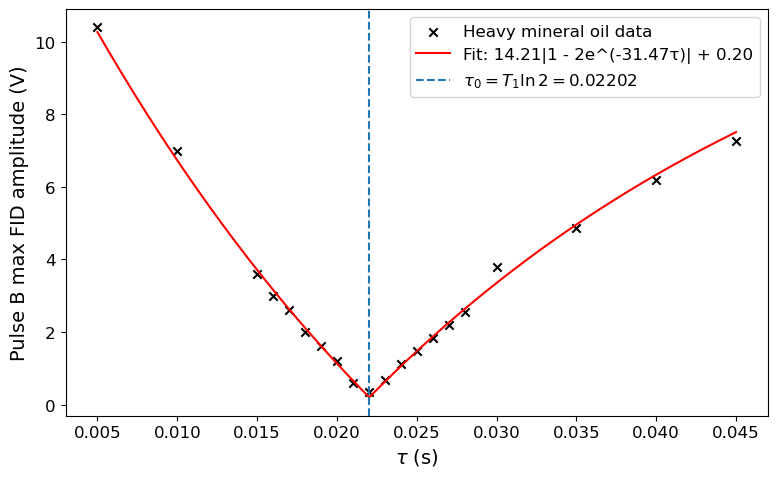

A  = 14.2133 ± 0.203349
T1 = 0.0317726 ± 0.000126048
C  = 0.197729 ± 0.0567245


In [4]:
tau_HO_T1 = [0.0050,0.0100,0.0150,0.0160,0.0170,0.0180,0.0190,0.0200,0.0210,0.0220,0.0230,0.0240,0.0250,0.0260,0.0270,0.0280,0.0300,0.0350,0.0400,0.0450]
V_HO_T1 = [10.40,7.00,3.60,3.00,2.60,2.00,1.60,1.20,0.58,0.34,0.67,1.11,1.48,1.84,2.20,2.56,3.80,4.88,6.20,7.28]

popt_HO_T1, pcov_HO_T1 = inversion_recovery(tau_HO_T1, V_HO_T1, lbl='Heavy mineral oil')

## $T_2$

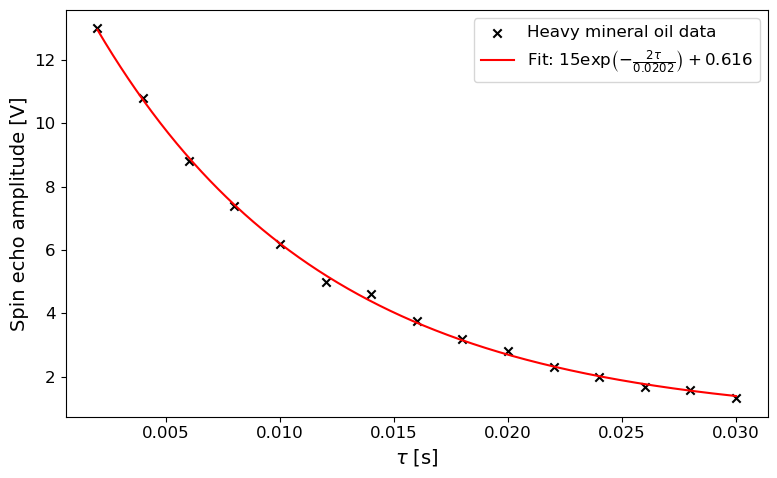

A0 = 15.0432 ± 0.123124
T2 = 0.0202169 ± 0.000516996
C  = 0.615816 ± 0.10774


In [5]:
tau_HO_T2 = [0.0020*i for i in range(1,16)]
V_HO_T2 = [13.00,10.80,8.80,7.40,6.20,5.00,4.60,3.76,3.20,2.80,2.32,2.00,1.68,1.58,1.32]

result_HO_T2 = spin_echo(tau_HO_T2, V_HO_T2, lbl='Heavy mineral oil')

## OU parameters

In [6]:
# Parameters
gamma = 2.678e8
f_rec_HO = 21.02330e6
T1_HO = popt_HO_T1[1]
T2_HO = result_HO_T2['T2']
omega0_HO = 2*np.pi*f_rec_HO

tau_c_HO, Delta2_HO, sigma_HO = OU_params(T1_HO, T2_HO, omega0_HO, gamma)

print(tau_c_HO)
print(Delta2_HO)
print(sigma_HO)

8.094221881746194e-09
2.9050107486330233e-08
2.679176449545645


# Light mineral oil

## $T_1$

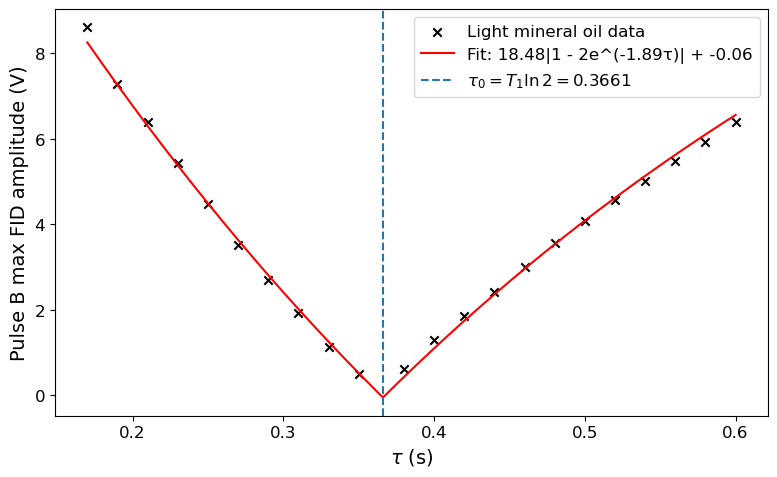

A  = 18.4822 ± 0.249821
T1 = 0.528161 ± 0.00129389
C  = -0.0587162 ± 0.0618875


In [7]:
tau_LO_T1 = [0.170, 0.190, 0.210, 0.230, 0.250, 0.270, 0.290, 0.310, 0.330, 0.350, 0.380, 0.400, 0.420, 0.440, 0.460, 0.480, 0.500, 0.520, 0.540, 0.560, 0.580, 0.600]
V_LO_T1 = [8.60, 7.28, 6.40, 5.44, 4.48, 3.52, 2.68, 1.92, 1.12, 0.48, 0.60, 1.28, 1.84, 2.40, 3.00, 3.56, 4.08, 4.56, 5.00, 5.48, 5.92, 6.40]

popt_LO_T1, pcov_LO_T1 = inversion_recovery(tau_LO_T1, V_LO_T1, lbl='Light mineral oil')

## $T_2$

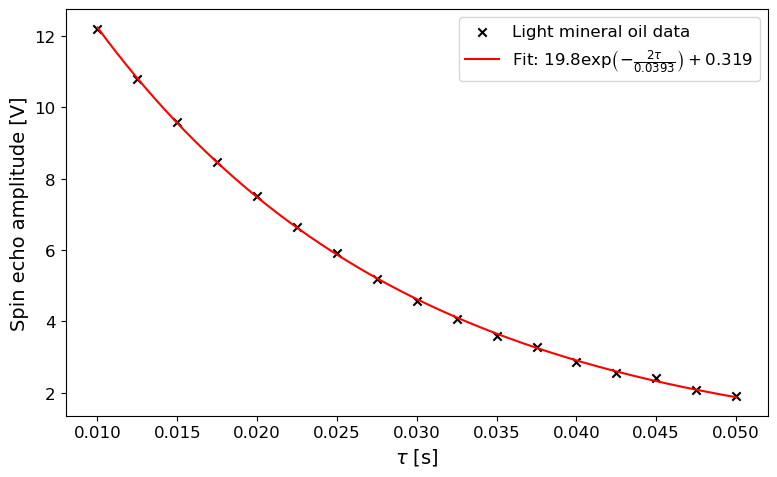

A0 = 19.8335 ± 0.0946507
T2 = 0.0392831 ± 0.000546188
C  = 0.318756 ± 0.0703867


In [8]:
tau_LO_T2 = [0.0100 + 0.0025*i for i in range(17)]
V_LO_T2 = [12.2, 10.8, 9.60, 8.48, 7.52, 6.64, 5.92, 5.20, 4.56, 4.08, 3.60, 3.28, 2.86, 2.56, 2.40, 2.08, 1.92]

result_LO_T2 = spin_echo(tau_LO_T2, V_LO_T2, lbl='Light mineral oil')

## OU parameters

In [9]:
# Parameters
gamma = 2.678e8
f_rec_LO = 21.12730e6
T1_LO = popt_LO_T1[1]
T2_LO = result_LO_T2['T2']
omega0_LO = 2*np.pi*f_rec_LO

tau_c_LO, Delta2_LO, sigma_LO = OU_params(T1_LO, T2_LO, omega0_LO, gamma)

print(tau_c_LO)
print(Delta2_LO)
print(sigma_LO)

3.7582735896946976e-08
4.546691831861497e-09
0.4918906432271841


# OU simulations

## Field and autocorrelation

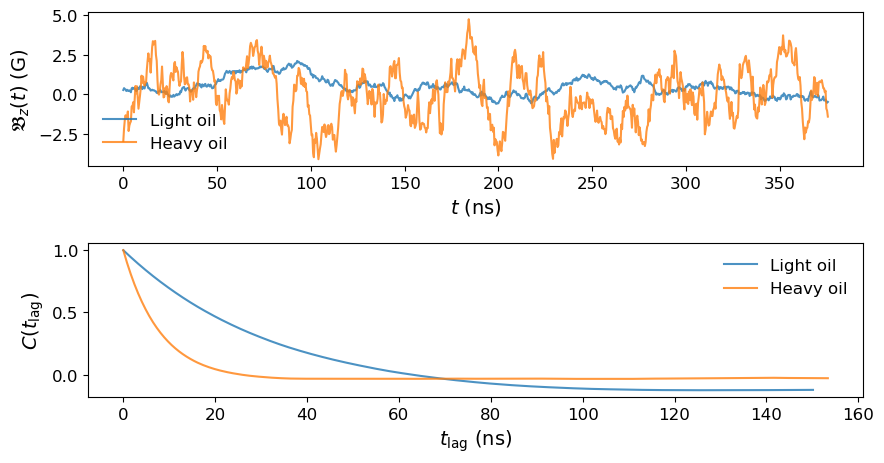

In [10]:
tau_c_min = min(tau_c_LO, tau_c_HO)
dt = tau_c_min / 20   # resolve correlation time
t_max = 10 * max(tau_c_LO, tau_c_HO)

t = np.arange(0, t_max, dt)

rng = np.random.default_rng()

B_LO = simulate_ou_field(
    n_traj=2000,
    t=t,
    tau_c=tau_c_LO,
    sigma=sigma_LO,
    rng=rng
)
B_light = B_LO[0]

B_HO = simulate_ou_field(
    n_traj=2000,
    t=t,
    tau_c=tau_c_HO,
    sigma=sigma_HO,
    rng=rng
)
B_heavy = B_HO[0]

C_LO = autocorr_ensemble(B_LO)
C_HO = autocorr_ensemble(B_HO)

t_lag_LO = t[:len(C_LO)]
t_lag_HO = t[:len(C_HO)]

mask_LO = t_lag_LO < 4 * tau_c_LO
mask_HO = t_lag_HO < 19 * tau_c_HO

fig, ax = plt.subplots(2,1, figsize=(10,5))

ax[0].plot(t * 1e9, B_light * 1e4, label="Light oil", alpha=0.8)
ax[0].plot(t * 1e9, B_heavy * 1e4, label="Heavy oil", alpha=0.8)

ax[0].set_xlabel(r"$t\ (\mathrm{ns})$")
ax[0].set_ylabel(r"$\mathfrak{B}_z(t)\ (\mathrm{G})$")
ax[0].legend(frameon=False, loc='lower left')

ax[1].plot(t_lag_LO[mask_LO] * 1e9, C_LO[mask_LO], label="Light oil", alpha=0.8)
ax[1].plot(t_lag_HO[mask_HO] * 1e9, C_HO[mask_HO], label="Heavy oil", alpha=0.8)

ax[1].set_xlabel(r"$t_{\mathrm{lag}}\ (\mathrm{ns})$")
ax[1].set_ylabel(r"$C(t_{\mathrm{lag}})$")
ax[1].legend(frameon=False, loc='upper right')

plt.subplots_adjust(hspace=0.5)

fig.savefig('e3_presentation/figures/OU_field_autocorr.png', bbox_inches='tight')
plt.show()

## Phase accumulation and spread

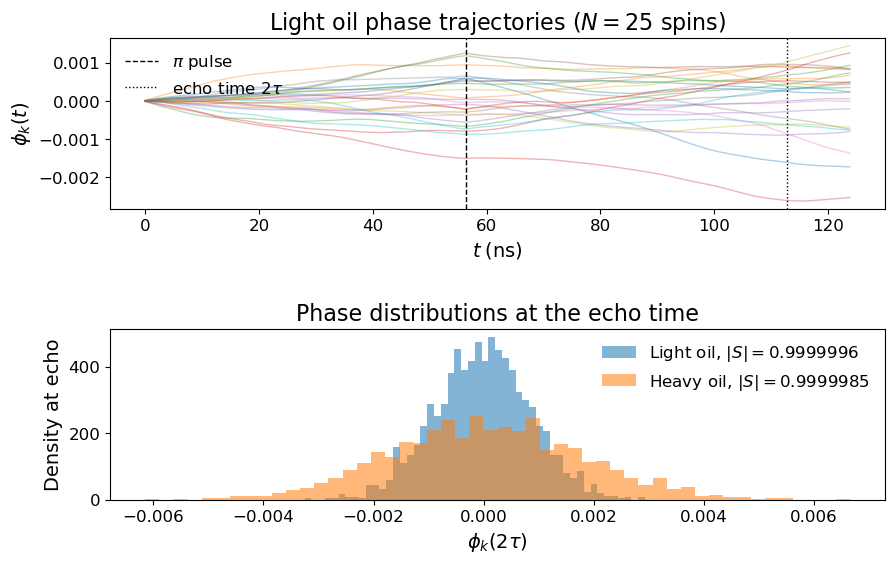

In [11]:
tau = 1.5*max(tau_c_LO, tau_c_HO)
n_show = 25
t_cut = 2 * tau * 1.1
mask = t <= t_cut

# Hahn toggling function
y = hahn_toggling_function(t, tau)

# Phase accumulation for both samples
phi_LO = stochastic_phase(B_LO, t, gamma, y=y)
phi_HO = stochastic_phase(B_HO, t, gamma, y=y)

# Coherence signals
S_LO = ensemble_average(phi_LO)
S_HO = ensemble_average(phi_HO)

echo_idx = np.argmin(np.abs(t - 2*tau))

phi_final_LO = phi_LO[:, echo_idx]
phi_final_HO = phi_HO[:, echo_idx]

echo_amp_LO = np.abs(S_LO[echo_idx])
echo_amp_HO = np.abs(S_HO[echo_idx])

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# ------------------------------------------------------------
# 2. Phase trajectories
# ------------------------------------------------------------
for k in range(n_show):
    ax[0].plot(t[mask] * 1e9, phi_LO[k, mask], alpha=0.35, linewidth=1)

ax[0].axvline(tau * 1e9, linestyle="--", color="k", linewidth=1, label=r"$\pi$ pulse")
ax[0].axvline(2*tau * 1e9, linestyle=":", color="k", linewidth=1, label=r"echo time $2\tau$")

ax[0].set_xlabel(r"$t\;(\mathrm{ns})$")
ax[0].set_ylabel(r"$\phi_k(t)$")
ax[0].set_title(r"Light oil phase trajectories ($N=25$ spins)")
ax[0].legend(frameon=False, loc='upper left')

# ------------------------------------------------------------
# 3. Phase distribution at echo time
# ------------------------------------------------------------
ax[1].hist(phi_final_LO, bins=50, density=True, alpha=0.55, label=rf"Light oil, $|S|={echo_amp_LO:.7f}$")
ax[1].hist(phi_final_HO, bins=50, density=True, alpha=0.55, label=rf"Heavy oil, $|S|={echo_amp_HO:.7f}$")
ax[1].set_xlabel(r"$\phi_k(2\tau)$")
ax[1].set_ylabel("Density at echo")
ax[1].set_title(r"Phase distributions at the echo time")
ax[1].legend(frameon=False)

plt.subplots_adjust(hspace=0.7)

fig.savefig('e3_presentation/figures/phase_distribution.png', bbox_inches='tight')
plt.show()

## Simulation and experiment comparison

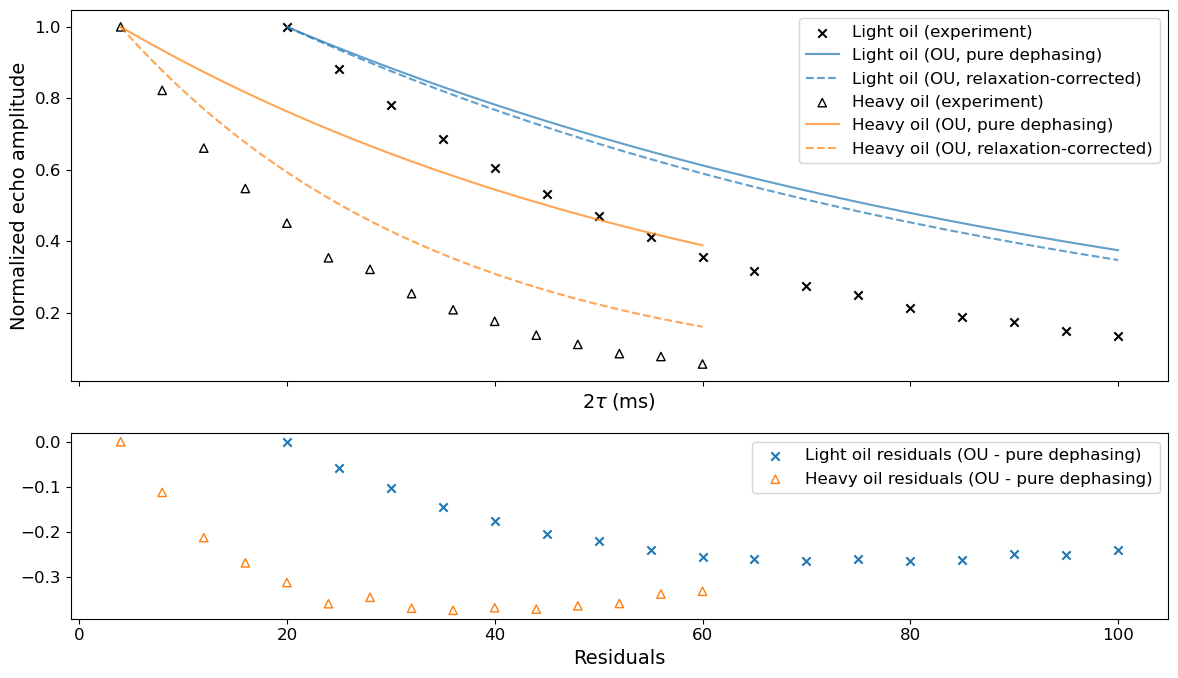

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# Prepare experimental data (both samples)
# ============================================================

tau_exp_LO = np.asarray(tau_LO_T2, dtype=float)
echo_exp_LO = np.asarray(V_LO_T2, dtype=float) - result_LO_T2['C']
echo_exp_norm_LO = echo_exp_LO / np.max(echo_exp_LO)

tau_exp_HO = np.asarray(tau_HO_T2, dtype=float)
echo_exp_HO = np.asarray(V_HO_T2, dtype=float) - result_HO_T2['C']
echo_exp_norm_HO = echo_exp_HO / np.max(echo_exp_HO)

# ============================================================
# Analytic OU predictions
# ============================================================

# --------- Not relaxation-corrected ---------
tau_grid_LO = np.linspace(np.min(tau_exp_LO), np.max(tau_exp_LO), 400)
tau_grid_HO = np.linspace(np.min(tau_exp_HO), np.max(tau_exp_HO), 400)

echo_pred_LO, params_LO = ou_hahn_echo_analytic(
    tau_grid_LO,
    T1=T1_LO,
    T2=T2_LO,
    omega0=omega0_LO,
    gamma=2.675e8,
)

echo_pred_HO, params_HO = ou_hahn_echo_analytic(
    tau_grid_HO,
    T1=T1_HO,
    T2=T2_HO,
    omega0=omega0_HO,
    gamma=2.675e8,
)

# Normalize predictions
echo_pred_norm_LO = echo_pred_LO / np.max(echo_pred_LO)
echo_pred_norm_HO = echo_pred_HO / np.max(echo_pred_HO)

# --------- Relaxation-corrected ---------
echo_pred_LO_corr, params_LO_corr = ou_hahn_echo_analytic(
    tau_grid_LO,
    T1=T1_LO,
    T2=T2_LO,
    omega0=omega0_LO,
    gamma=2.675e8,
    correction=True
)

echo_pred_HO_corr, params_HO_corr = ou_hahn_echo_analytic(
    tau_grid_HO,
    T1=T1_HO,
    T2=T2_HO,
    omega0=omega0_HO,
    gamma=2.675e8,
    correction=True
)

# Normalize predictions
echo_pred_norm_LO_corr = echo_pred_LO_corr / np.max(echo_pred_LO_corr)
echo_pred_norm_HO_corr = echo_pred_HO_corr/ np.max(echo_pred_HO_corr)

# ============================================================
# Plot both on same axis
# ============================================================

fig, ax = plt.subplots(2,1, figsize=(12,7), sharex=True, gridspec_kw={'height_ratios': [3, 1.5]})

# --- Light oil ---
ax[0].scatter(
    2 * tau_exp_LO * 1e3,
    echo_exp_norm_LO,
    marker='x',
    color='k',
    label="Light oil (experiment)"
)

ax[0].plot(
    2 * tau_grid_LO * 1e3,
    echo_pred_norm_LO,
    color='tab:blue',
    linestyle='-',
    label="Light oil (OU, pure dephasing)",
    alpha=0.7
)   # not corrected

ax[0].plot(
    2 * tau_grid_LO * 1e3,
    echo_pred_norm_LO_corr,
    color='tab:blue',
    linestyle='--',
    label="Light oil (OU, relaxation-corrected)",
    alpha=0.7
)   # relaxation-corrected

# --- Heavy oil ---
ax[0].scatter(
    2 * tau_exp_HO * 1e3,
    echo_exp_norm_HO,
    marker='^',
    color='k',
    label="Heavy oil (experiment)",
    facecolors='none'
)   # raw

ax[0].plot(
    2 * tau_grid_HO * 1e3,
    echo_pred_norm_HO,
    color='tab:orange',
    linestyle='-',
    label="Heavy oil (OU, pure dephasing)",
    alpha=0.7
)   # no correction

ax[0].plot(
    2 * tau_grid_HO * 1e3,
    echo_pred_norm_HO_corr,
    color='tab:orange',
    linestyle='--',
    label="Heavy oil (OU, relaxation-corrected)",
    alpha=0.7
)   # relaxation-corrected

# ============================================================
# Formatting
# ============================================================

ax[0].set_xlabel(r"$2\tau\;(\mathrm{ms})$")
ax[0].set_ylabel("Normalized echo amplitude")
ax[0].legend(loc='upper right')

# Interpolate OU predictions to experimental points
f_LO = interp1d(2*tau_grid_LO*1e3, echo_pred_norm_LO,
                bounds_error=False, fill_value="extrapolate")
f_HO = interp1d(2*tau_grid_HO*1e3, echo_pred_norm_HO,
                bounds_error=False, fill_value="extrapolate")

x_LO = 2*tau_exp_LO*1e3
x_HO = 2*tau_exp_HO*1e3

res_LO = echo_exp_norm_LO - f_LO(x_LO)
res_HO = echo_exp_norm_HO - f_HO(x_HO)

ax[1].scatter(x_LO, res_LO, color='tab:blue', marker='x', label='Light oil residuals (OU - pure dephasing)')
ax[1].scatter(x_HO, res_HO, facecolors='none',
              edgecolors='tab:orange', marker='^', label='Heavy oil residuals (OU - pure dephasing)')

ax[1].legend(loc='upper right')
ax[1].set_xlabel('Residuals')

plt.tight_layout()

# fig.savefig('e3_presentation/figures/OU_vs_exp.png')
fig.savefig('e3_writing/figures/OU_vs_exp.png')
plt.show()